# Sphere Function — 2D Contour & 3D Surface Visualization

Notebook này hiển thị **2D Contour Map** và **3D Surface Plot** của hàm **Sphere**.

$$f(\mathbf{x}) = \sum_{i=1}^{n} x_i^2$$

- **Global minimum**: $f(0, \ldots, 0) = 0$
- **Domain**: $[-5.12,\; 5.12]^n$ (typical)
- Hàm unimodal, convex — không có local optima, tâm là điểm min duy nhất.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
if not os.path.isdir(os.path.join(sys.path[0], 'AIP')):
    sys.path[0] = os.path.join(os.getcwd(), 'src')

import numpy as np
import matplotlib.pyplot as plt

from AIP.problems.continuous.sphere import Sphere

print('Imports OK')

Imports OK


## 1. Setup — Tạo grid 2D

In [2]:
# 2-D Sphere problem
problem = Sphere(n_dim=2)

# Grid for contour & surface
x_lin = np.linspace(-5.12, 5.12, 200)
y_lin = np.linspace(-5.12, 5.12, 200)
X, Y  = np.meshgrid(x_lin, y_lin)
grid  = np.column_stack([X.ravel(), Y.ravel()])
Z     = problem.eval(grid).reshape(X.shape)

print(f'Z range: [{Z.min():.2f}, {Z.max():.2f}]')

Z range: [0.00, 52.43]


## 2. Side-by-side: 2D Contour Map + 3D Surface Plot

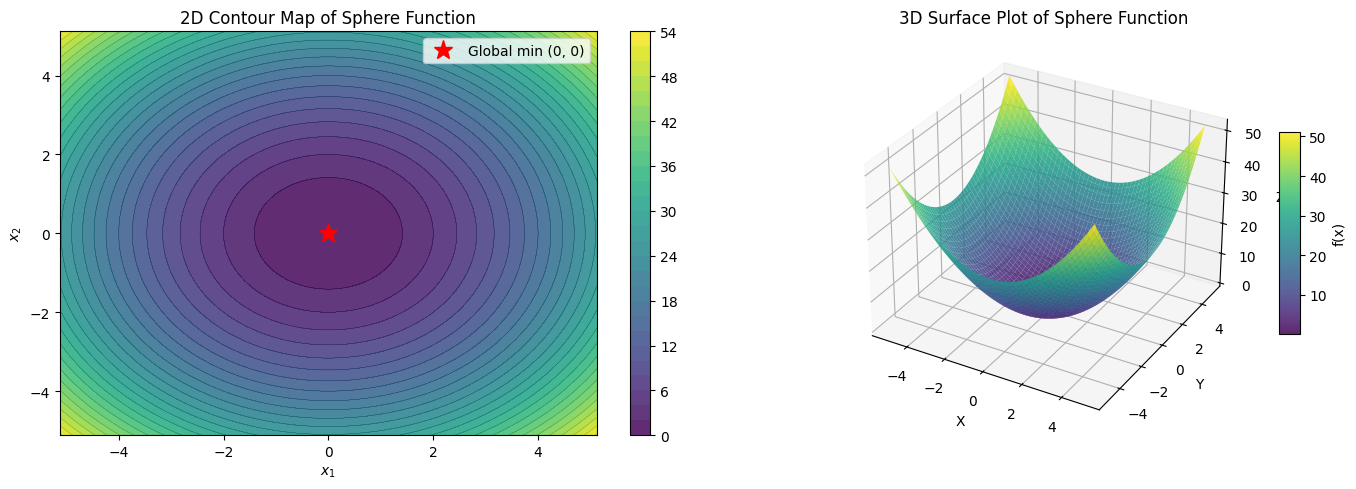

Saved → ../report/figures/sphere_landscape.png


In [ ]:
fig = plt.figure(figsize=(14, 5))

# ── Left: 2D Contour Map ──────────────────────────────────────
ax2d = fig.add_subplot(1, 2, 1)
cf = ax2d.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.85)
cs = ax2d.contour( X, Y, Z, levels=30, colors='k',  linewidths=0.3, alpha=0.3)
plt.colorbar(cf, ax=ax2d)
ax2d.plot(0, 0, 'r*', markersize=14, label='Global min (0, 0)', zorder=5)
ax2d.set_title('2D Contour Map of Sphere Function')
ax2d.set_xlabel('$x_1$')
ax2d.set_ylabel('$x_2$')
ax2d.legend(loc='upper right')

# ── Right: 3D Surface Plot ────────────────────────────────────
ax3d = fig.add_subplot(1, 2, 2, projection='3d')

# Denser mesh for smoother 3D surface
x3 = np.linspace(-5.12, 5.12, 150)
y3 = np.linspace(-5.12, 5.12, 150)
X3, Y3 = np.meshgrid(x3, y3)
Z3 = problem.eval(np.column_stack([X3.ravel(), Y3.ravel()])).reshape(X3.shape)

surf = ax3d.plot_surface(X3, Y3, Z3, cmap='viridis', alpha=0.85,
                         linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label='f(x)')
ax3d.set_title('3D Surface Plot of Sphere Function')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.savefig('figures/sphere_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/sphere_landscape.png')

## 3. Chi tiết: 2D Contour Map riêng lẻ

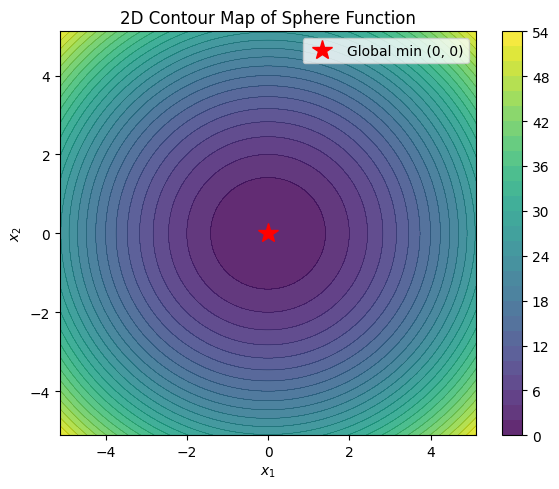

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.85)
cs = ax.contour( X, Y, Z, levels=30, colors='k', linewidths=0.3, alpha=0.3)
plt.colorbar(cf, ax=ax)
ax.plot(0, 0, 'r*', markersize=15, label='Global min (0, 0)', zorder=5)
ax.set_title('2D Contour Map of Sphere Function')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Chi tiết: 3D Surface Plot riêng lẻ

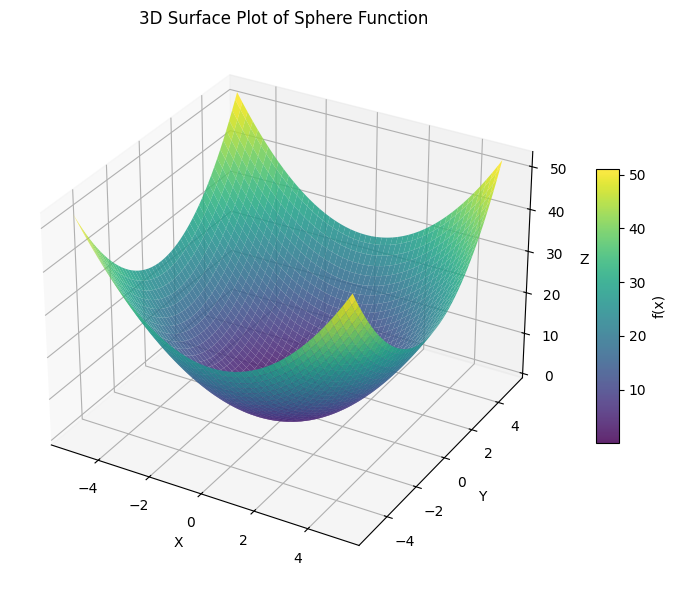

In [7]:
fig3 = plt.figure(figsize=(8, 6))
ax3d = fig3.add_subplot(111, projection='3d')

surf = ax3d.plot_surface(X3, Y3, Z3, cmap='viridis', alpha=0.85,
                         linewidth=0, antialiased=True)
fig3.colorbar(surf, ax=ax3d, shrink=0.5, aspect=12, label='f(x)')
ax3d.set_title('3D Surface Plot of Sphere Function')
ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()